# Предварительное исследование данных для приложения

In [105]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier

from sklearn.impute import SimpleImputer

from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

Установим глобальные переменные

## Загрузка данных

In [2]:
RANDOM_STATE=52
TEST_SIZE=0.25

Загрузим данные

In [3]:
df_heart = pd.read_csv('datasets/heart_train.csv')
df_heart_test = pd.read_csv('datasets/heart_test.csv')

Рассмотрим их поближе

In [4]:
df_heart.head()

,Unnamed: 0,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,...,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk (Binary),Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure,id
0,0,0.359551,0.732143,0.074244,1.0,1.0,1.0,1.0,1.0,0.535505,...,3.0,0.333333,0.0,0.227018,0.048229,0.036512,Male,0.212903,0.709302,2664
1,1,0.202247,0.325000,0.047663,1.0,1.0,0.0,0.0,1.0,0.068690,...,3.0,0.833333,0.0,0.150198,0.017616,0.000194,Female,0.412903,0.569767,9287
2,2,0.606742,0.860714,0.055912,1.0,0.0,1.0,1.0,1.0,0.944001,...,2.0,1.000000,0.0,0.227018,0.048229,0.036512,Female,0.238710,0.220930,5379
3,3,0.730337,0.007143,0.053162,0.0,0.0,1.0,0.0,1.0,0.697023,...,0.0,0.333333,1.0,0.227018,0.048229,0.036512,Female,0.348387,0.267442,8222
4,4,0.775281,0.757143,0.021998,0.0,0.0,1.0,0.0,1.0,0.412878,...,5.0,1.000000,1.0,0.227018,0.048229,0.036512,Male,0.619355,0.441860,4047


In [5]:
df_heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8685 entries, 0 to 8684
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       8685 non-null   int64  
 1   Age                              8685 non-null   float64
 2   Cholesterol                      8685 non-null   float64
 3   Heart rate                       8685 non-null   float64
 4   Diabetes                         8442 non-null   float64
 5   Family History                   8442 non-null   float64
 6   Smoking                          8442 non-null   float64
 7   Obesity                          8442 non-null   float64
 8   Alcohol Consumption              8442 non-null   float64
 9   Exercise Hours Per Week          8685 non-null   float64
 10  Diet                             8685 non-null   int64  
 11  Previous Heart Problems          8442 non-null   float64
 12  Medication Use      

Сразу видны пропуски, данные отмасштабированы, но это не значит что предобработка не нужна

Выделим таргет

In [6]:
target = 'Heart Attack Risk (Binary)'

Уберём столбец который являлся идентификатором

In [7]:
df_heart.drop(columns=['Unnamed: 0'], inplace=True)

Много признаков, разберёмся с ними в исследовательском анализе

In [8]:
df_heart.columns

Index(['Age', 'Cholesterol', 'Heart rate', 'Diabetes', 'Family History',
       'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week',
       'Diet', 'Previous Heart Problems', 'Medication Use', 'Stress Level',
       'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides',
       'Physical Activity Days Per Week', 'Sleep Hours Per Day',
       'Heart Attack Risk (Binary)', 'Blood sugar', 'CK-MB', 'Troponin',
       'Gender', 'Systolic blood pressure', 'Diastolic blood pressure', 'id'],
      dtype='object')

Установим столбец `id` как идентификатор датасета

In [9]:
df_heart.set_index('id', inplace=True)
df_heart.head()

,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,...,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk (Binary),Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure
id,,,,,,,,,,,,,,,,,,,,,
2664,0.359551,0.732143,0.074244,1.0,1.0,1.0,1.0,1.0,0.535505,1,...,0.979221,3.0,0.333333,0.0,0.227018,0.048229,0.036512,Male,0.212903,0.709302
9287,0.202247,0.325000,0.047663,1.0,1.0,0.0,0.0,1.0,0.068690,2,...,0.515584,3.0,0.833333,0.0,0.150198,0.017616,0.000194,Female,0.412903,0.569767
5379,0.606742,0.860714,0.055912,1.0,0.0,1.0,1.0,1.0,0.944001,2,...,0.012987,2.0,1.000000,0.0,0.227018,0.048229,0.036512,Female,0.238710,0.220930
8222,0.730337,0.007143,0.053162,0.0,0.0,1.0,0.0,1.0,0.697023,0,...,0.131169,0.0,0.333333,1.0,0.227018,0.048229,0.036512,Female,0.348387,0.267442
4047,0.775281,0.757143,0.021998,0.0,0.0,1.0,0.0,1.0,0.412878,1,...,0.070130,5.0,1.000000,1.0,0.227018,0.048229,0.036512,Male,0.619355,0.441860


Сразу заметна проблема с столбцом `Gender` - приведём все значения к одному типу - целочисленному

In [10]:
df_heart['Gender'].value_counts()

Gender
Male      5882
Female    2560
1.0        156
0.0         87
Name: count, dtype: int64

In [11]:
df_heart.loc[df_heart['Gender'] == 'Male', 'Gender'] = '1.0'
df_heart.loc[df_heart['Gender'] == 'Female', 'Gender'] = '0.0'

df_heart['Gender'] = pd.to_numeric(df_heart['Gender'], errors='coerce')

In [12]:
df_heart['Gender'].value_counts()

Gender
1.0    6038
0.0    2647
Name: count, dtype: int64

Всё прошло без ошибок

Заполним пропуски, заполнять будем медианными значениями для всех типов столбцов

In [13]:
def restore_dtypes(df, dtypes):
    for col in df.columns.tolist():
        df[col] = df[col].astype(dtypes[col])
    return df

In [14]:
numeric_cols = df_heart.drop(target, axis=1).select_dtypes(include=np.number).columns.tolist()
categorical_cols = df_heart.drop(target, axis=1).select_dtypes(exclude=np.number).columns.tolist()

In [15]:
numeric_transformer = Pipeline(steps=[
    ('imputer_nan', SimpleImputer(missing_values=np.nan, strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer_nan', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
])

In [16]:
data_preparer = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough'
)

In [17]:
original_dtypes = df_heart.dtypes
df_heart = restore_dtypes(pd.DataFrame(data_preparer.fit_transform(df_heart), 
                                      columns=numeric_cols+categorical_cols+[target]),
                        original_dtypes)
df_heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8685 entries, 0 to 8684
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              8685 non-null   float64
 1   Cholesterol                      8685 non-null   float64
 2   Heart rate                       8685 non-null   float64
 3   Diabetes                         8685 non-null   float64
 4   Family History                   8685 non-null   float64
 5   Smoking                          8685 non-null   float64
 6   Obesity                          8685 non-null   float64
 7   Alcohol Consumption              8685 non-null   float64
 8   Exercise Hours Per Week          8685 non-null   float64
 9   Diet                             8685 non-null   int64  
 10  Previous Heart Problems          8685 non-null   float64
 11  Medication Use                   8685 non-null   float64
 12  Stress Level        

In [18]:
df_heart.duplicated().sum()

0

Пропуски убрали, перейдём к EDA

## Исследовательский анализ данных (EDA)

Рассмотрим что значат признаки в реальной жизни, для понимания картины

### Описание признаков датасета сердечно-сосудистых заболеваний

#### Демографические данные
- **Age (Возраст)** - возраст пациента в годах. Один из ключественных факторов риска сердечно-сосудистых заболеваний
- **Gender (Пол)** - пол пациента (мужской/женский). Влияет на гормональный фон и предрасположенность к сердечным заболеваниям

#### Антропометрические данные
- **BMI (Индекс массы тела)** - показатель соотношения веса и роста человека (кг/м²). Используется для оценки нормальности веса:
  - <18.5 - дефицит массы тела
  - 18.5-24.9 - норма
  - 25-29.9 - избыточный вес
  - ≥30 - ожирение

#### Лабораторные показатели крови
- **Cholesterol (Холестерин)** - общий холестерин крови (ммоль/л или мг/дл). Жироподобное вещество, участвующее в построении клеток
- **Triglycerides (Триглицериды)** - тип жиров в крови, основной источник энергии. Повышенный уровень связан с риском сердечно-сосудистых заболеваний
- **Blood sugar (Сахар крови)** - уровень глюкозы в крови (ммоль/л). Важный показатель углеводного обмена
- **CK-MB (Креатинкиназа-МВ)** - сердечный изофермент, маркер повреждения сердечной мышцы. Повышается при инфаркте миокарда
- **Troponin (Тропонин)** - белок, специфичный для сердечной мышцы. Золотой стандарт диагностики инфаркта миокарда

#### Сердечно-сосудистые показатели
- **Heart rate (Частота пульса)** - количество ударов сердца в минуту (уд/мин). Норма: 60-90 уд/мин в покое
- **Systolic blood pressure (Систолическое давление)** - верхнее давление, давление в артериях в момент сокращения сердца (мм рт.ст.)
- **Diastolic blood pressure (Диастолическое давление)** - нижнее давление, давление в артериях в момент расслабления сердца (мм рт.ст.)

#### Факторы риска и образ жизни
- **Diabetes (Диабет)** - наличие сахарного диабета (0 - нет, 1 - есть)
- **Family History (Семейный анамнез)** - наличие сердечно-сосудистых заболеваний у близких родственников
- **Smoking (Курение)** - статус курения (0 - не курит, 1 - курит)
- **Obesity (Ожирение)** - наличие ожирения (0 - нет, 1 - есть)
- **Alcohol Consumption (Употребление алкоголя)** - статус употребления алкоголя (0 - не употребляет, 1 - употребляет)
- **Exercise Hours Per Week (Часы упражнений в неделю)** - количество часов физической активности в неделю
- **Diet (Диета)** - тип питания (вероятно, категориальный признак: 0 - нездоровое, 1 - здоровое)
- **Previous Heart Problems (Предыдущие проблемы с сердцем)** - наличие в анамнезе сердечно-сосудистых заболеваний
- **Medication Use (Прием лекарств)** - регулярный прием сердечно-сосудистых препаратов
- **Stress Level (Уровень стресса)** - субъективная или объективная оценка уровня стресса
- **Sedentary Hours Per Day (Малоподвижные часы в день)** - количество часов, проводимых в сидячем положении
- **Physical Activity Days Per Week (Дни физической активности в неделю)** - количество дней в неделю с физической нагрузкой
- **Sleep Hours Per Day (Часы сна в день)** - средняя продолжительность сна

#### Социально-экономические факторы
- **Income (Доход)** - уровень дохода пациента (может влиять на доступность медицинской помощи и качество жизни)

#### Целевая переменная
- **Heart Attack Risk (Binary) (Риск инфаркта)** - бинарный показатель наличия риска инфаркта миокарда (0 - низкий риск, 1 - высокий риск)

Напишем унифицированную функцию для показа графиков

In [19]:
def graphical_eda_report(df):
    for col in df.columns:
        plt.figure(figsize=(10, 5))
        if df[col].dtype == 'object':
            sns.countplot(data=df, x=col, hue=target)
            plt.title(f'Count Plot of {col}')
        else:
            sns.histplot(data=df, x=col, hue=target, kde=True)
            plt.title(f'Histogram of {col}')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

Перейдём к данным, рассматривать будем гистограммы и столбчатые диаграммы в зависимости от типов данных, оттенком подчеркнём таргет

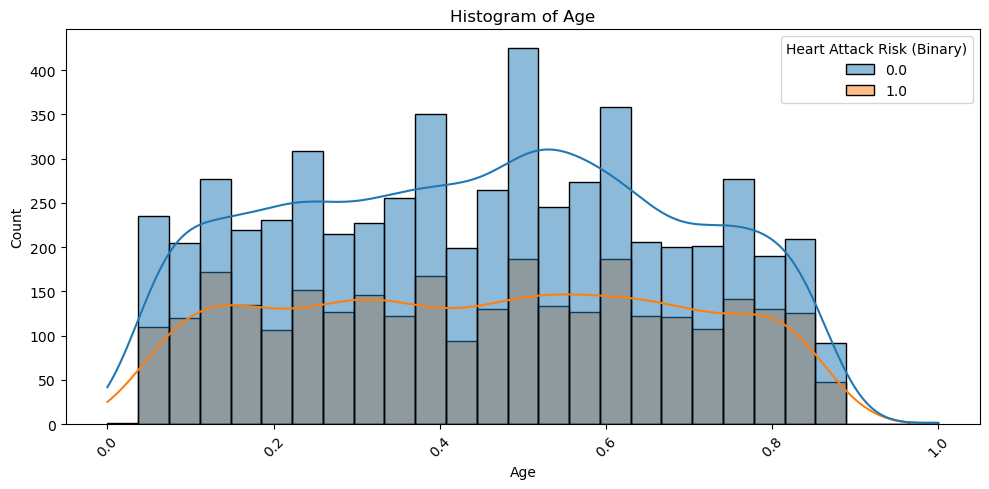

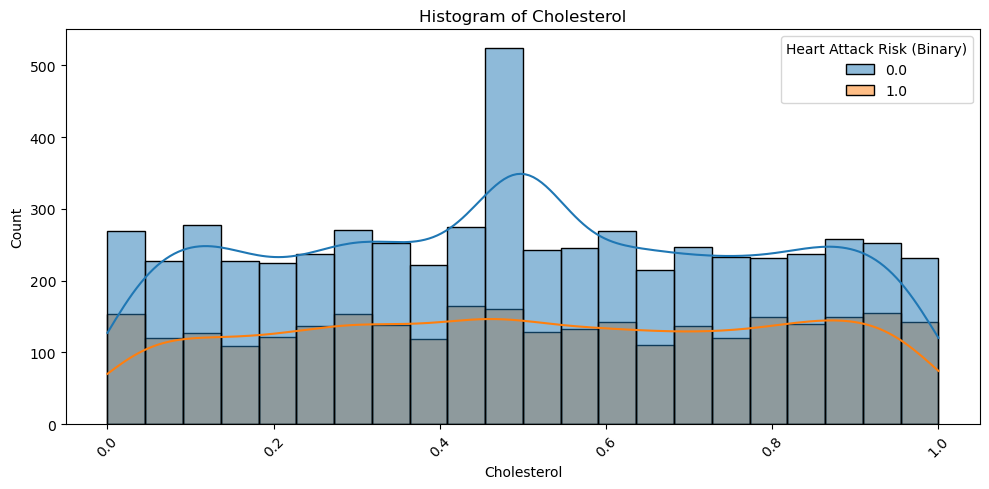

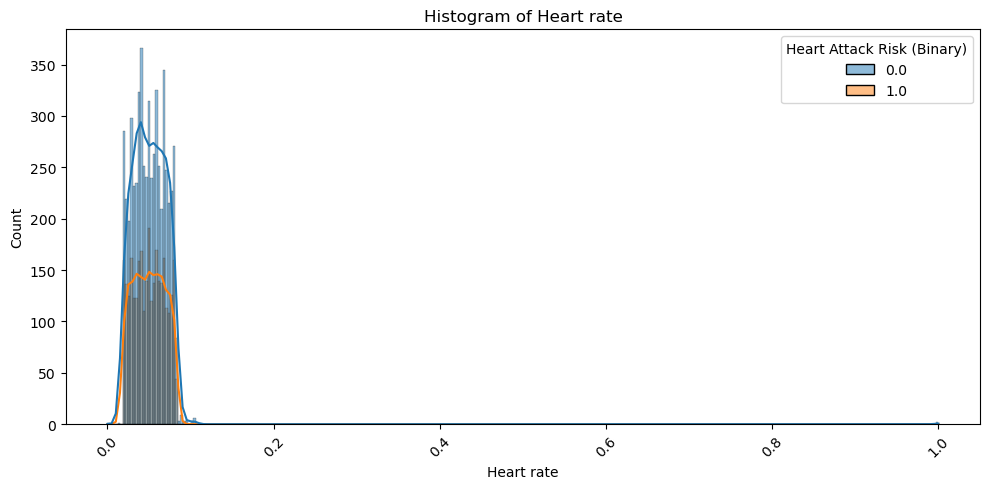

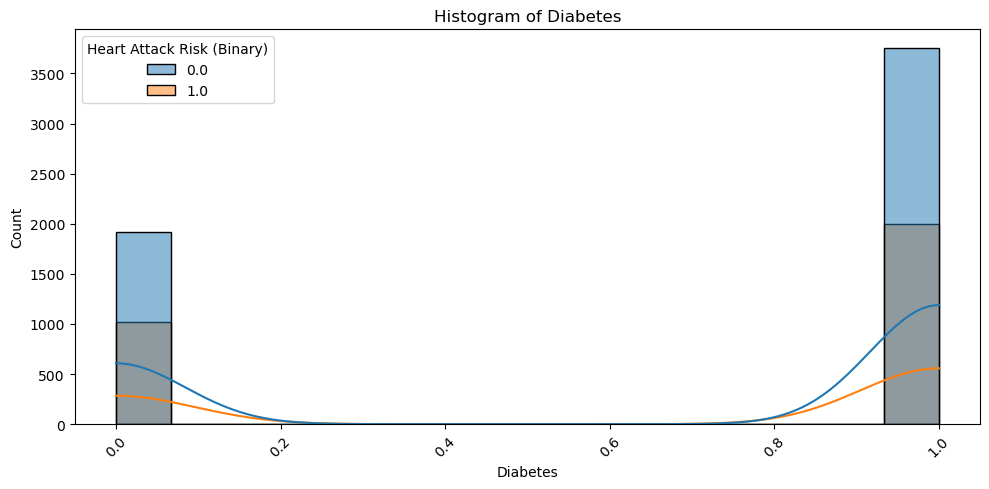

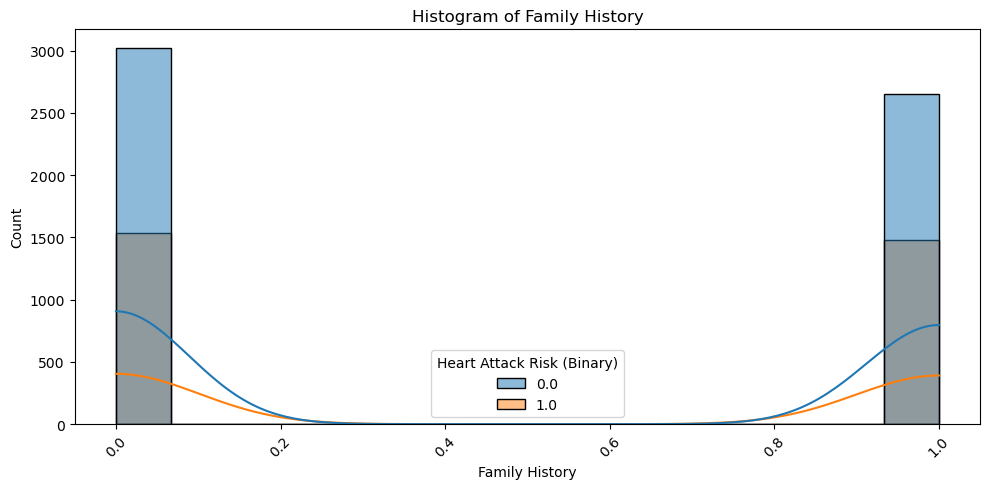

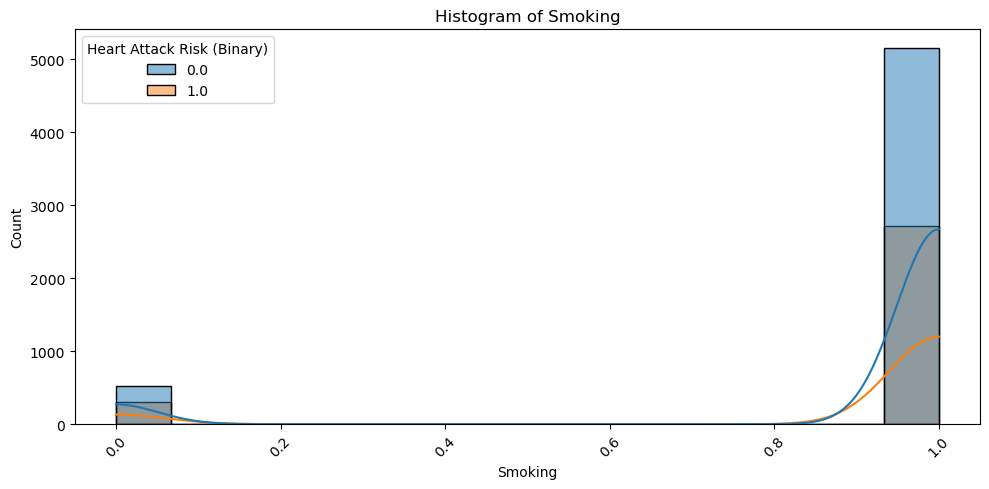

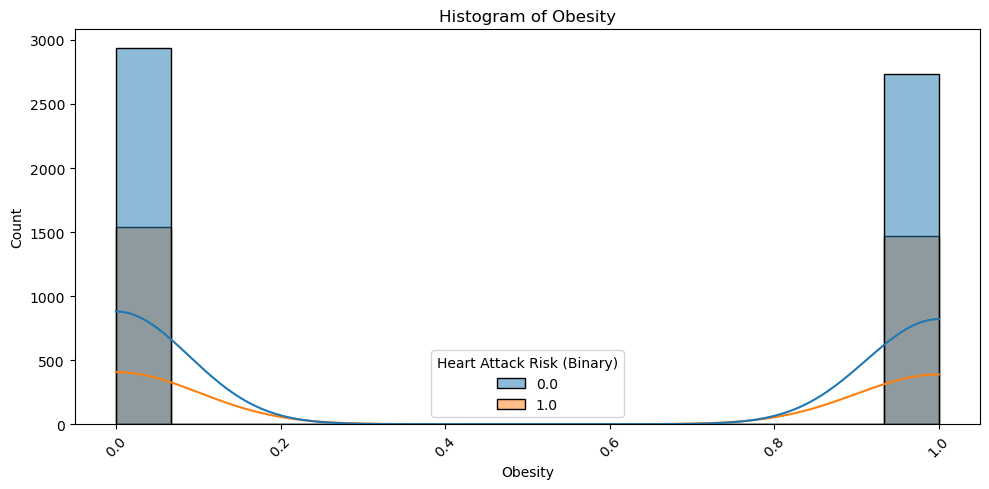

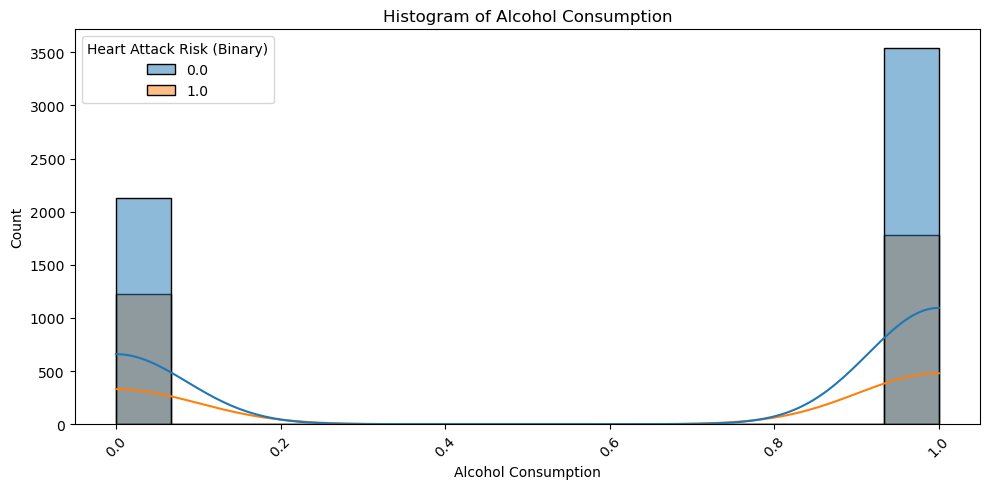

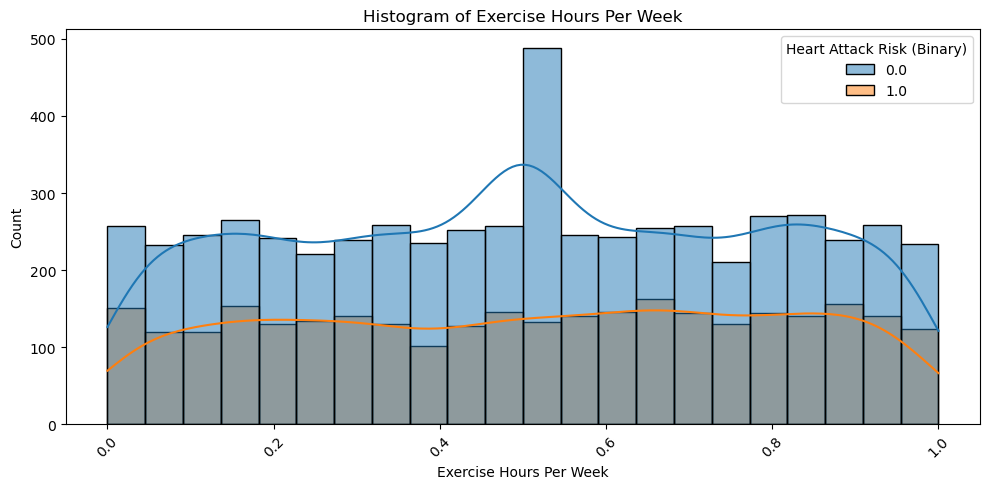

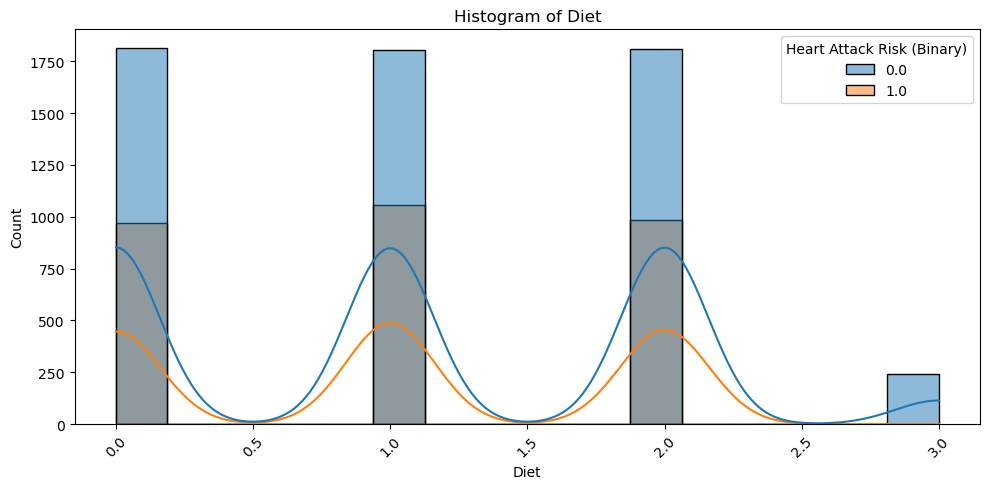

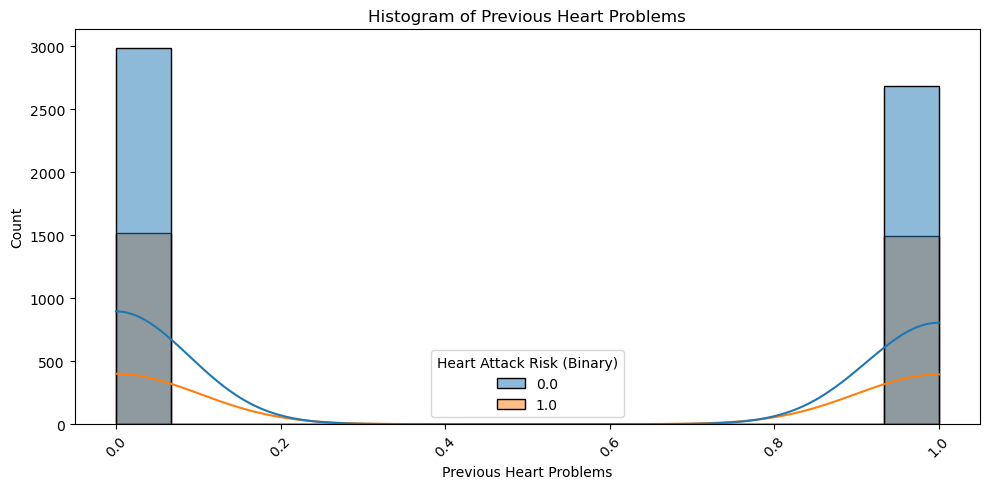

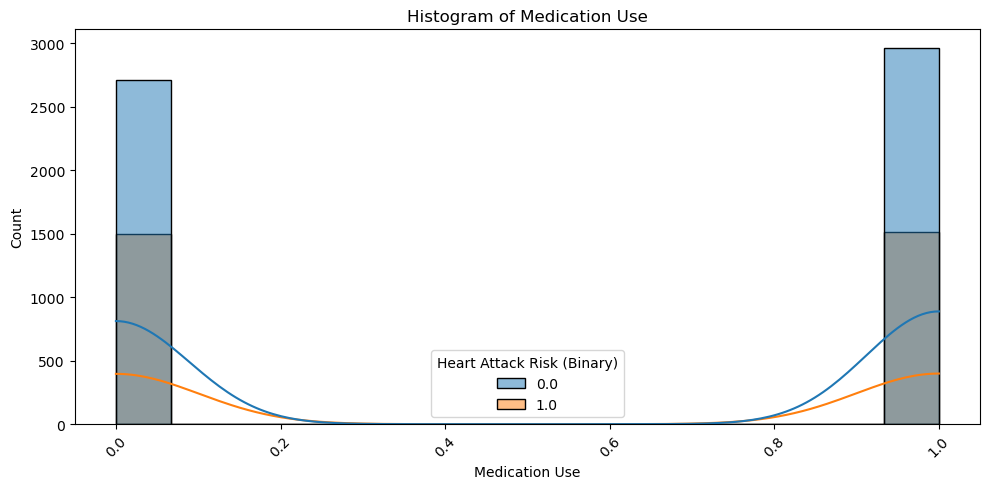

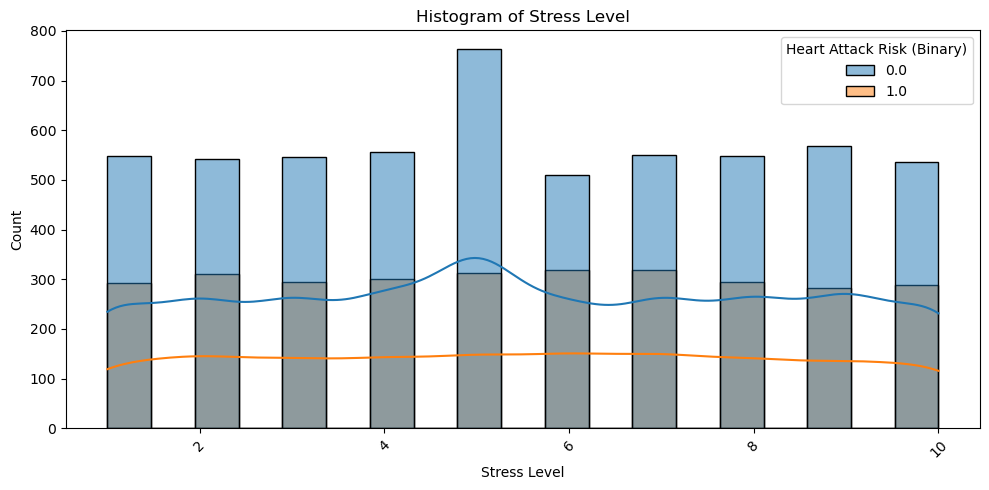

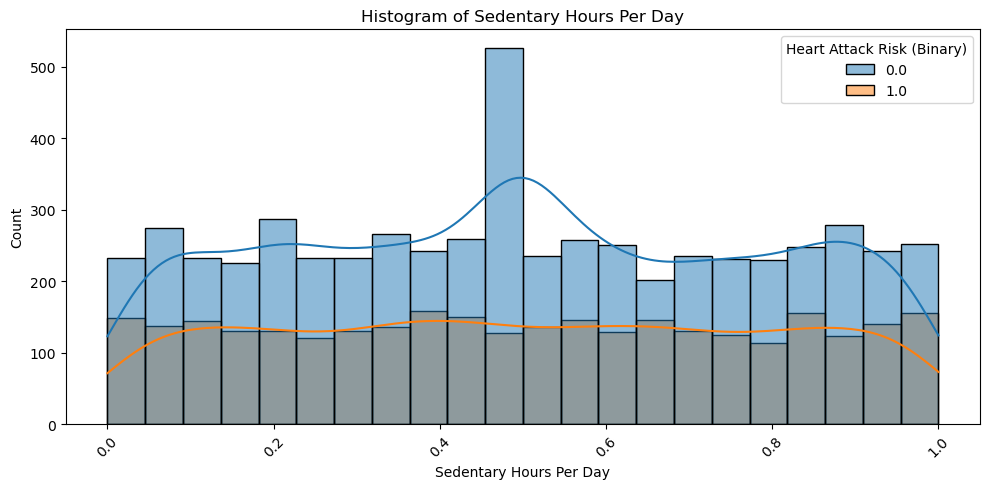

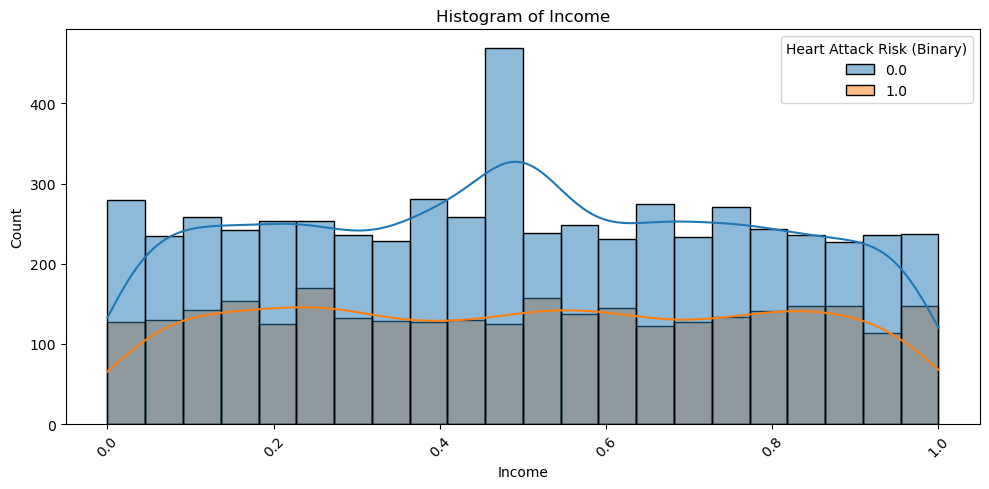

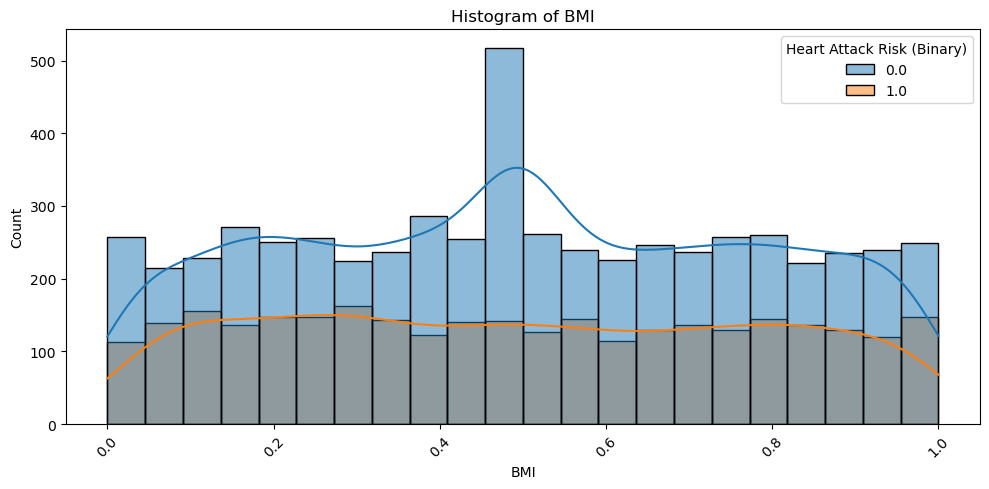

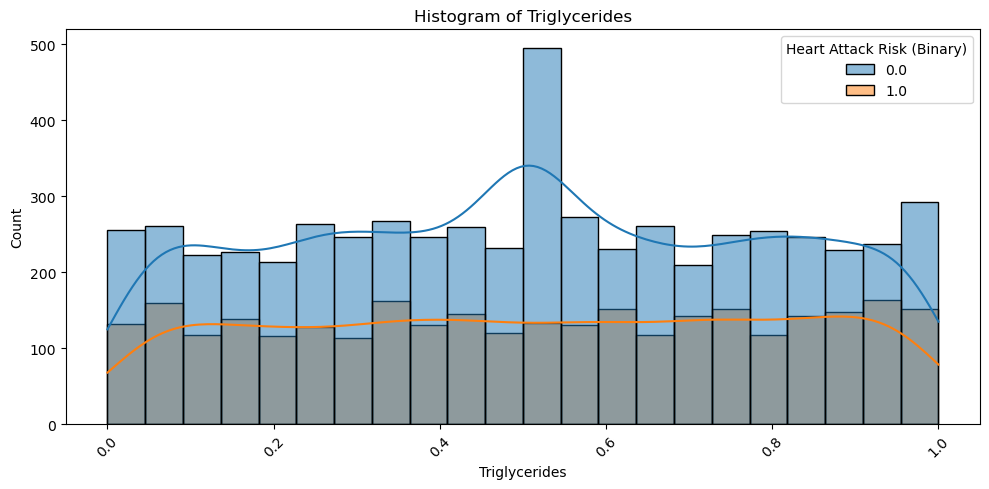

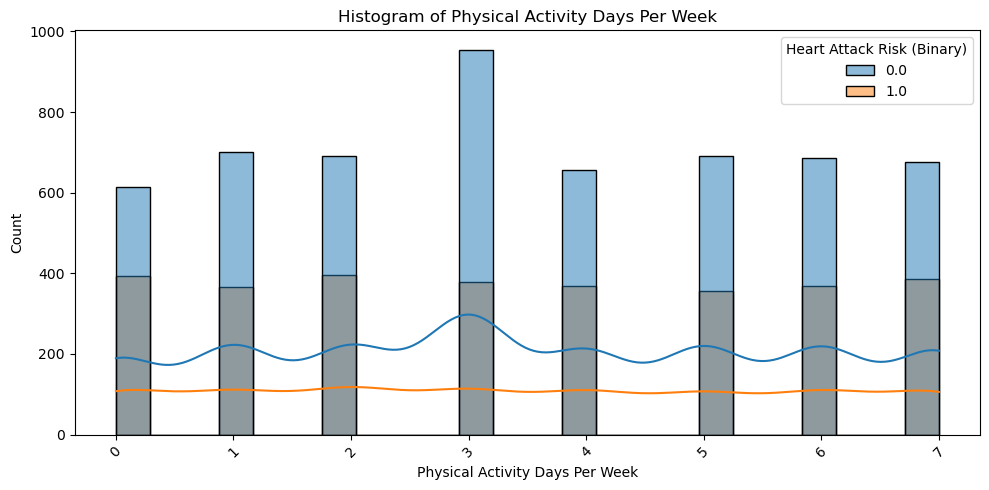

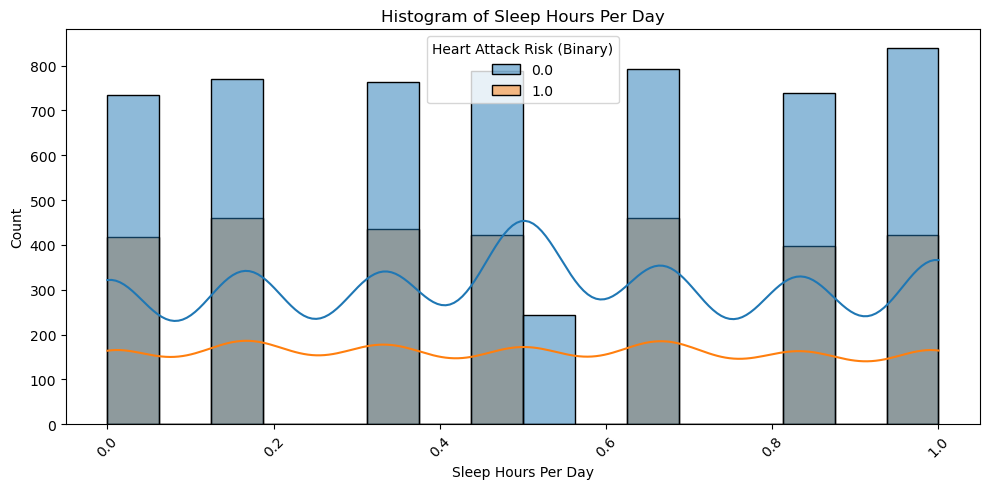

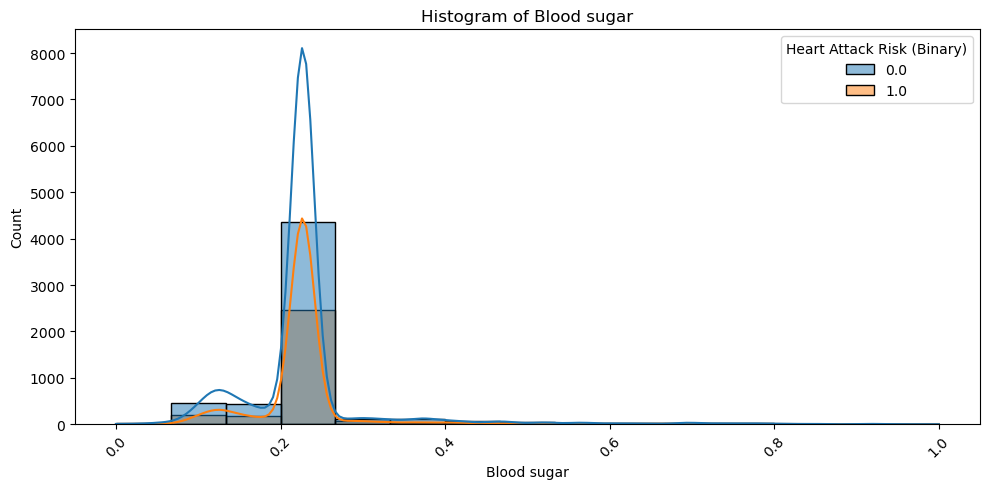

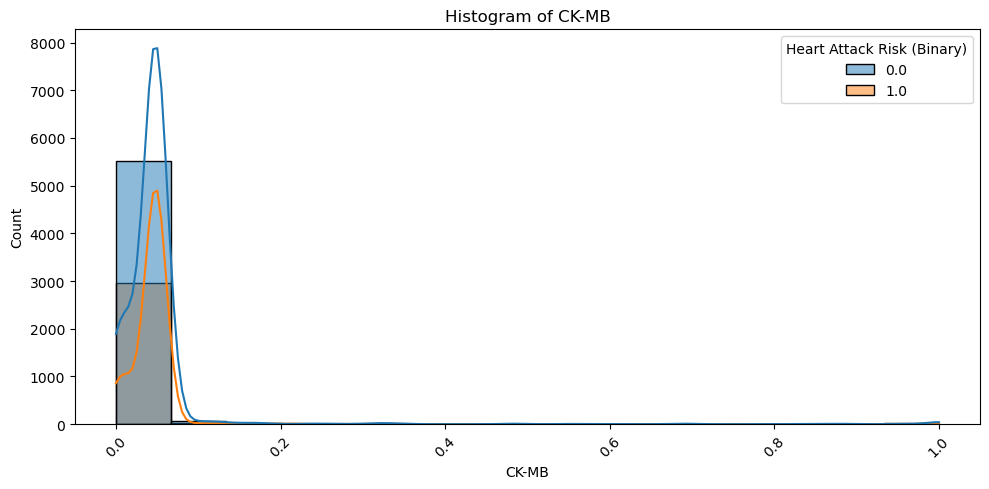

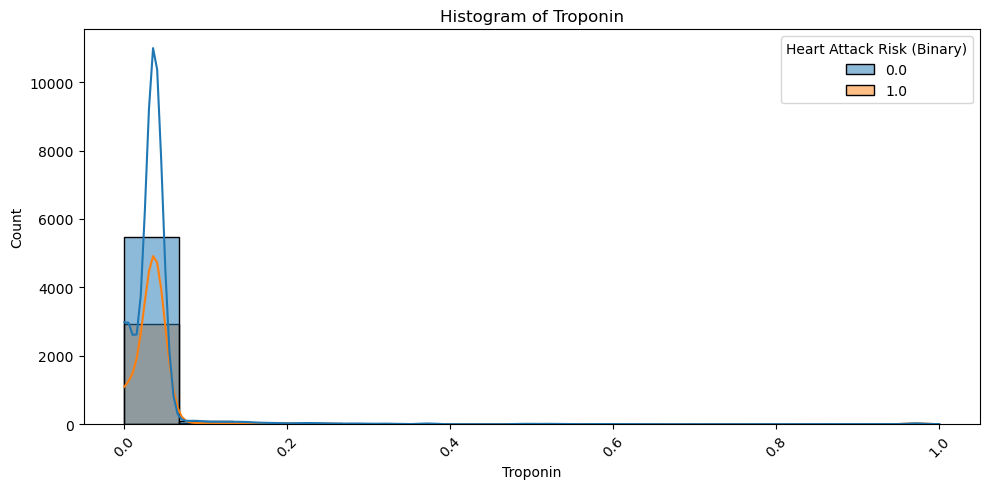

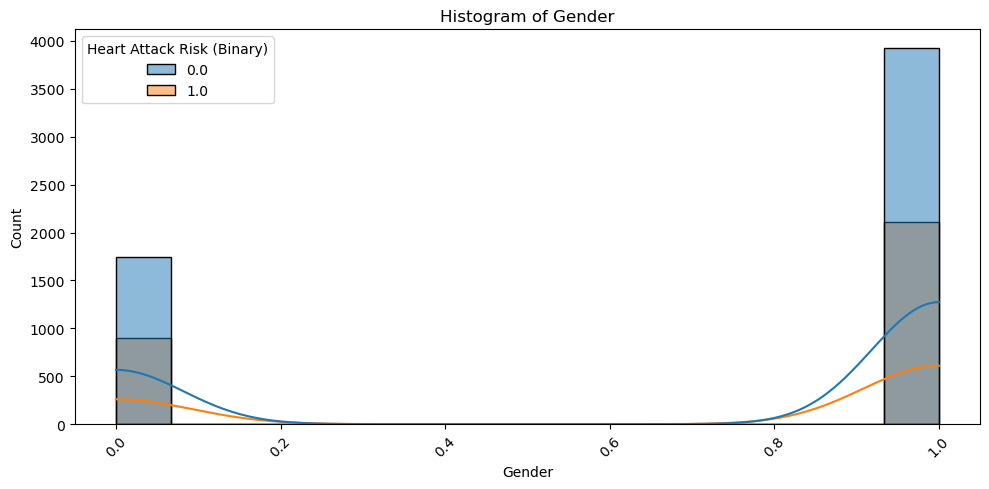

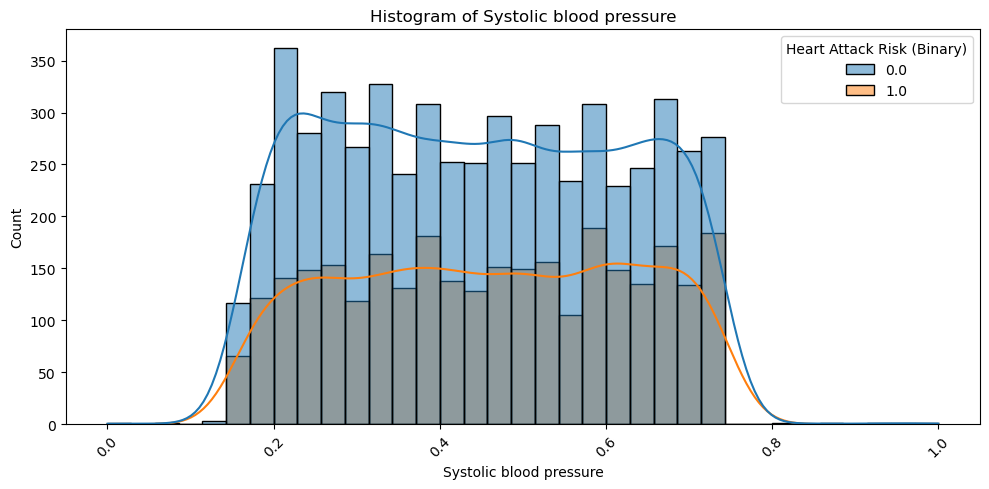

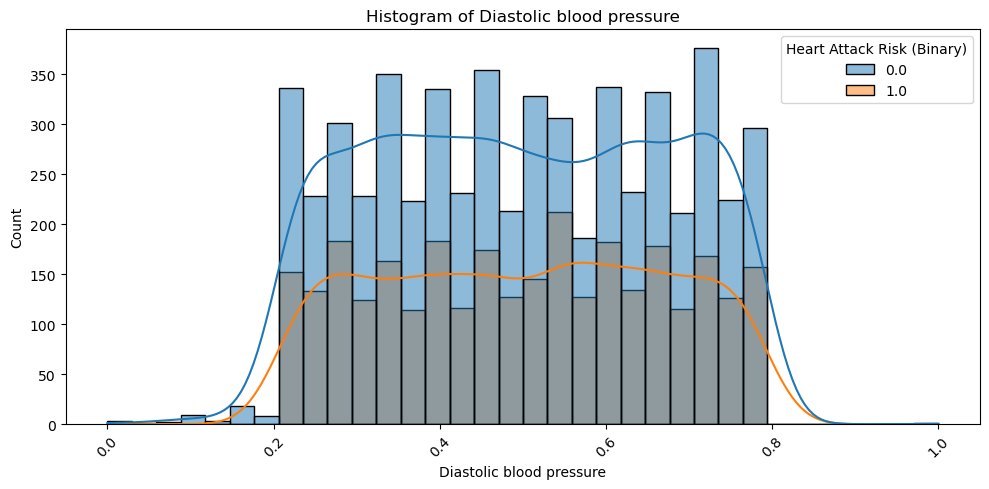

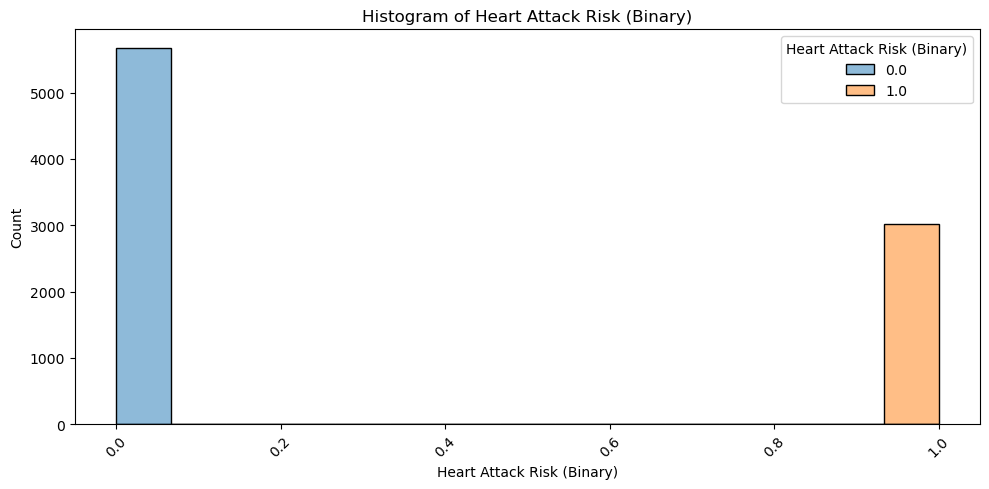

In [20]:
graphical_eda_report(df_heart)

Тяжело рассматривать данные, т.к. они приведены к одному масштабу (скорее всего чтобы не раскрывать реальные данные)
Будем придерживаться плану - закинуть данные в скейлер (на всякий случай, мы не знаем что за масштабирование применялось), потом скормить модели. Дополнительно рассмотрим вес признаков

Полезно также рассмотреть матрицу корреляции, на случай если признаки мультикоррелируют

In [21]:
def preprocess_data(df):
    df_processed = df.copy()
    
    for column in df_processed.columns:
        if df_processed[column].dtype == 'object':
            # Преобразуем строки в категориальные коды
            df_processed[column] = pd.Categorical(df_processed[column]).codes
    
    return df_processed

# Применяем преобразование
data_processed = preprocess_data(df_heart)

<Axes: >

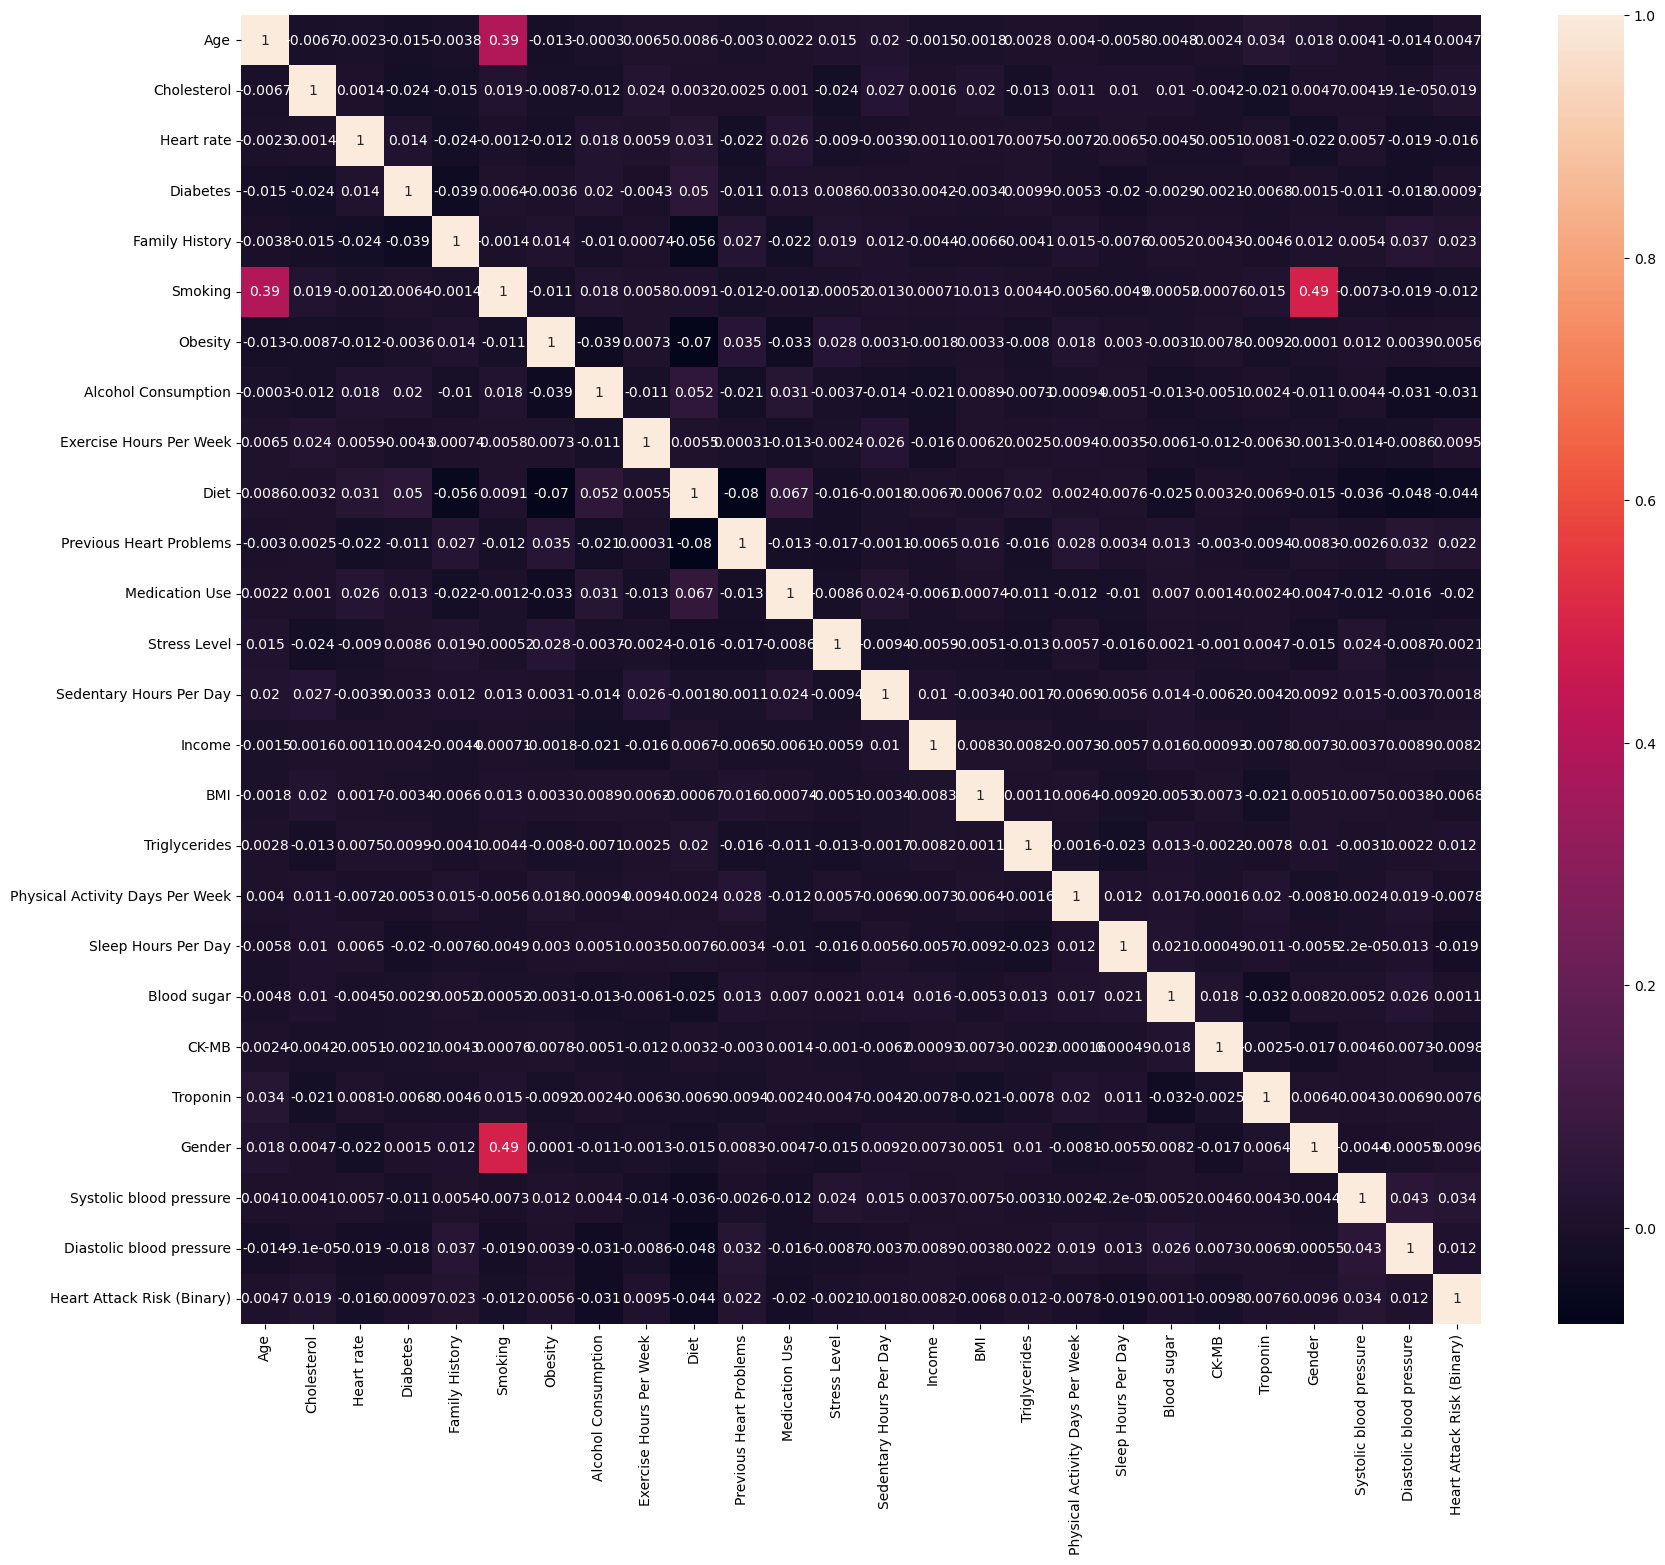

In [22]:
plt.figure(figsize=(20, 17))
sns.heatmap(data = preprocess_data(df_heart).corr(method='pearson'),  annot=True)

Мультикорреляции не обнаружено, перейдём к обучению

## Подготовка данных и обучение моделей

Будем использовать несколько моделей, потом выберем лучшую. Поэкспериментируем с классическими моделями, также посмотрим на работу алгоритма случайного леса и категориального бустинга

В качестве метрики будем максимизировать recall, т.к. лучше отправить на дообследование здорового пациента, чем домой инфарктного (минимизируем False Negative ошибку), для этого на кросс валидации зададим метрику roc-auc, а затем подкоректируем порог классификации у лучшей модели. Таким образом получим удоволетворительный recall и не получим модель которая будет говорить отправлять всех пациентов (здоровых/не здоровых) на дообследование

In [23]:
numeric_cols = df_heart.drop(target, axis=1).select_dtypes(include=np.number).columns.tolist()

Выделим валидационную выборку, чтобы обнаружить переобучение на всякий случай

In [75]:
X_train, X_val, y_train, y_val = train_test_split(df_heart.drop(target, axis=1), 
                                                  df_heart[target], test_size=TEST_SIZE, random_state=RANDOM_STATE)

In [76]:
num_columns = X_train.select_dtypes(include=np.number).columns.tolist()

In [77]:
data_preprocessor = ColumnTransformer(
    [
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

In [78]:
pipe_tree = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

tree_param_grid = {
        'models__max_depth': [3, 5, 7, 10, 15, 20, None],
        'models__min_samples_split': [2, 5, 10, 15, 20],
        'models__min_samples_leaf': [1, 2, 4, 6, 8, 10],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']  
    }

rand_search_tree = RandomizedSearchCV(
    pipe_tree, 
    tree_param_grid, 
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rand_search_tree.fit(X_train, y_train)

print('Лучшая модель и её параметры:', rand_search_tree.best_params_)
print ('Метрика лучшей модели на тренировочной выборке:', rand_search_tree.best_score_)

Лучшая модель и её параметры: {'preprocessor__num': MinMaxScaler(), 'models__min_samples_split': 10, 'models__min_samples_leaf': 8, 'models__max_depth': None}
Метрика лучшей модели на тренировочной выборке: 0.5417737083670161


In [79]:
pipe_lr = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', LogisticRegression(random_state=RANDOM_STATE))
])

lr_param_grid = {
        'models__fit_intercept': [True, False],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']  
    }

rand_search_lr = RandomizedSearchCV(
    pipe_lr, 
    lr_param_grid, 
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rand_search_lr.fit(X_train, y_train)

print('Лучшая модель и её параметры:', rand_search_lr.best_params_)
print ('Метрика лучшей модели на тренировочной выборке:', rand_search_lr.best_score_)

Лучшая модель и её параметры: {'preprocessor__num': RobustScaler(), 'models__fit_intercept': True}
Метрика лучшей модели на тренировочной выборке: 0.5275019750188896


c:\Users\lastc\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [80]:
pipe_svc = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', SVC(kernel='rbf'))
])

svc_param_grid = {
    'models__C': [0.1, 1, 10],
    'models__gamma': ['scale', 0.1, 0.01],
    'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
}

rand_search_svc = RandomizedSearchCV(
    pipe_svc, 
    svc_param_grid, 
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rand_search_svc.fit(X_train, y_train)

print('Лучшая модель и её параметры:', rand_search_svc.best_params_)
print ('Метрика лучшей модели на тренировочной выборке:', rand_search_svc.best_score_)

Лучшая модель и её параметры: {'preprocessor__num': 'passthrough', 'models__gamma': 0.1, 'models__C': 1}
Метрика лучшей модели на тренировочной выборке: 0.5497984883064448


In [81]:
pipe_rfc = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', RandomForestClassifier(random_state=RANDOM_STATE))
])
rfc_param_grid = {
    'models__n_estimators': [100, 200, 300],
    'models__max_depth': [3, 5, 7, 10, 15, 20, None],
    'models__min_samples_split': [2, 5, 10],
    'models__min_samples_leaf': [1, 2, 4],
    'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']  
}

rand_search_rfc = RandomizedSearchCV(
    pipe_rfc,
    rfc_param_grid, 
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rand_search_rfc.fit(X_train, y_train)
print('Лучшая модель и её параметры:', rand_search_rfc.best_params_)
print ('Метрика лучшей модели на тренировочной выборке:', rand_search_rfc.best_score_)

Лучшая модель и её параметры: {'preprocessor__num': 'passthrough', 'models__n_estimators': 200, 'models__min_samples_split': 5, 'models__min_samples_leaf': 2, 'models__max_depth': 15}
Метрика лучшей модели на тренировочной выборке: 0.5813129797244738


На тренировочной выборке лучше всего себя показал случайный лес, посмотрим его на валидационной выборке

In [102]:
threshold = 0.33

y_val_pred_proba = rand_search_rfc.best_estimator_.predict_proba(X_val)
roc_auc_val = roc_auc_score(y_val, y_val_pred_proba[:, 1])
print(f'ROC AUC на валидационной выборке: {roc_auc_val:.4f}')

y_val_pred = (y_val_pred_proba[:, 1] >= threshold).astype(int)
accuracy_val = accuracy_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
print(f'На валидационной выборке - Accuracy: {accuracy_val:.4f}, Recall: {recall_val:.4f}, ROC AUC: {roc_auc_val:.4f}')

ROC AUC на валидационной выборке: 0.5675
На валидационной выборке - Accuracy: 0.4830, Recall: 0.7029, ROC AUC: 0.5675


Результат не очень

Попробуем catboost

In [33]:
cat_features = ['Diabetes', 'Family History', 'Smoking', 'Obesity', 'Alcohol Consumption', 'Diet', 'Previous Heart Problems', 'Medication Use', 'Stress Level', 'Physical Activity Days Per Week', 'Gender']

In [34]:
def to_int(df, cat_cols):
    for col in cat_cols:
        df[col] = df[col].astype('int')
    return df

In [35]:
df_heart_cat = df_heart.copy()
df_heart_cat = to_int(df_heart_cat, cat_features)

In [83]:
X_cat_train, X_cat_val, y_cat_train, y_cat_val = train_test_split(df_heart_cat.drop(target, axis=1),
                                                              df_heart_cat[target], test_size=TEST_SIZE, random_state=RANDOM_STATE)

In [84]:
num_columns = df_heart_cat.select_dtypes(include='float64').columns
cat_columns = df_heart_cat.select_dtypes(include='int').columns


In [85]:
catboost_preprocessor = ColumnTransformer(
    [
     ('num', MinMaxScaler(), num_columns),
    ], 
    remainder='passthrough'
)

In [133]:
pipe_catboost = Pipeline([
    ('preprocessor', data_preprocessor),
    ('classifier', CatBoostClassifier(random_state=RANDOM_STATE))
])

catboost_param_grid = {
    'classifier__iterations': [100, 200, 300, 500],
    'classifier__depth': [3, 4, 5, 6, 8, 10],
    'classifier__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15, 0.2],
    'classifier__l2_leaf_reg': [1, 3, 5, 7, 10],
    'classifier__border_count': [32, 64, 128, 255],
    'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
}

rand_search_catboost = RandomizedSearchCV(
    pipe_catboost,
    catboost_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    n_iter=50  # количество случайных комбинаций параметров
)

rand_search_catboost.fit(X_cat_train, y_cat_train)
print('Лучшая модель и её параметры:', rand_search_catboost.best_params_)
print('Метрика лучшей модели на тренировочной выборке:', rand_search_catboost.best_score_)

0:	learn: 0.6911294	total: 14.5ms	remaining: 7.25s
1:	learn: 0.6889752	total: 28.1ms	remaining: 7s
2:	learn: 0.6872485	total: 41.9ms	remaining: 6.94s
3:	learn: 0.6854941	total: 53.7ms	remaining: 6.66s
4:	learn: 0.6835198	total: 66.1ms	remaining: 6.54s
5:	learn: 0.6816320	total: 79.3ms	remaining: 6.53s
6:	learn: 0.6799590	total: 92.2ms	remaining: 6.49s
7:	learn: 0.6780205	total: 105ms	remaining: 6.43s
8:	learn: 0.6764061	total: 118ms	remaining: 6.42s
9:	learn: 0.6749635	total: 130ms	remaining: 6.35s
10:	learn: 0.6737478	total: 142ms	remaining: 6.32s
11:	learn: 0.6723531	total: 155ms	remaining: 6.3s
12:	learn: 0.6701985	total: 167ms	remaining: 6.26s
13:	learn: 0.6687640	total: 180ms	remaining: 6.25s
14:	learn: 0.6671793	total: 194ms	remaining: 6.29s
15:	learn: 0.6657083	total: 207ms	remaining: 6.26s
16:	learn: 0.6641336	total: 220ms	remaining: 6.24s
17:	learn: 0.6623089	total: 233ms	remaining: 6.24s
18:	learn: 0.6611782	total: 247ms	remaining: 6.24s
19:	learn: 0.6594607	total: 260ms	rema

In [143]:
y_pred_proba = rand_search_catboost.predict_proba(X_cat_val)[:, 1]

threshold = 0.29

y_pred_catboost_custom = (y_pred_proba >= threshold).astype(int)

recall_catboost_custom = recall_score(y_cat_val, y_pred_catboost_custom)
accuracy_catboost_custom = accuracy_score(y_cat_val, y_pred_catboost_custom)
roc_auc_catboost_custom = roc_auc_score(y_cat_val, y_pred_proba)

print(f'CatBoost с порогом {threshold} - Recall: {recall_catboost_custom:.4f}, Accuracy: {accuracy_catboost_custom:.4f}, ROC AUC: {roc_auc_catboost_custom:.4f}')

CatBoost с порогом 0.29 - Recall: 0.8412, Accuracy: 0.4618, ROC AUC: 0.5890


In [137]:
rand_search_catboost.best_params_

{'preprocessor__num': 'passthrough',
 'classifier__learning_rate': 0.01,
 'classifier__l2_leaf_reg': 3,
 'classifier__iterations': 500,
 'classifier__depth': 10,
 'classifier__border_count': 255}

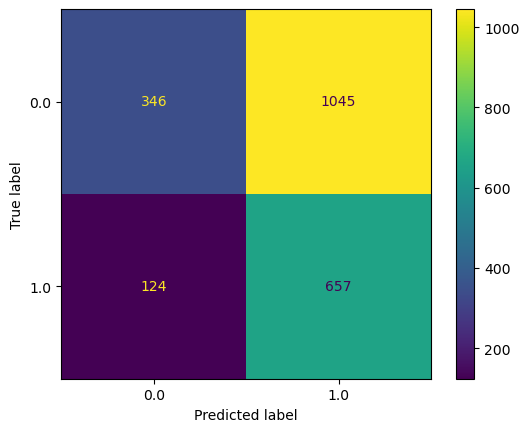

In [144]:
cm = confusion_matrix(y_cat_val, y_pred_catboost_custom, labels=rand_search_catboost.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=rand_search_catboost.classes_)
disp.plot()

## Итог

В прод выкатим catboost модель с параметрами     
```
{'preprocessor__num': 'passthrough',
 'classifier__learning_rate': 0.01,
 'classifier__l2_leaf_reg': 3,
 'classifier__iterations': 500,
 'classifier__depth': 10,
 'classifier__border_count': 255}
 ```
и порогом классификации `0.29`.
Метрики ужасные, но чуть лучше случайного предсказания, что может сохранить чуть денег и человеческих жизней